<a href="https://colab.research.google.com/github/tjpel/AIHC5020/blob/main/AIHC5020_Final_Pelowitz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
!pip install -q pydicom

In [16]:
import os
import re
import json
import math
from datetime import datetime, timezone

import pandas as pd
import matplotlib.pyplot as plt
import pydicom
from google.cloud import storage
from google.auth.credentials import AnonymousCredentials

## Problem 1: Summarizing Data Types in Python

In [17]:
types_data = [
    {'name': 'Integer', 'python_symbol': 'int', 'example': str(25), 'falsy_value': 0,
     'usage': 'Represents whole numbers'},
    {'name': 'Float', 'python_symbol': 'float', 'example': str(3.14), 'falsy_value': 0.0,
     'usage': 'Represents real numbers with a decimal point'},
    {'name': 'Complex', 'python_symbol': 'complex', 'example': str(2 + 3j), 'falsy_value': 0j,
     'usage': 'Represents numbers with real and imaginary parts'},
    {'name': 'Boolean', 'python_symbol': 'bool', 'example': str(True), 'falsy_value': False,
     'usage': 'Represents logical True/False values'},
    {'name': 'String', 'python_symbol': 'str', 'example': str('hello'), 'falsy_value': '',
     'usage': 'Represents sequences of text characters'},
    {'name': 'None', 'python_symbol': 'NoneType', 'example': str(None), 'falsy_value': None,
     'usage': 'Represents the absence of a value'},
    {'name': 'List', 'python_symbol': 'list', 'example': str([1, 2, 3]), 'falsy_value': [],
     'usage': 'Mutable ordered collection of items'},
    {'name': 'Tuple', 'python_symbol': 'tuple', 'example': str((1, 2, 3)), 'falsy_value': (),
     'usage': 'Immutable ordered collection of items'},
    {'name': 'Dictionary', 'python_symbol': 'dict', 'example': str({'a': 1, 'b': 2}), 'falsy_value': {},
     'usage': 'Mutable collection of key-value pairs'},
]

types_df = pd.DataFrame(types_data, columns=['name', 'python_symbol', 'example', 'falsy_value', 'usage'])
types_df

,name,python_symbol,example,falsy_value,usage
0,Integer,int,25,0,Represents whole numbers
1,Float,float,3.14,0.0,Represents real numbers with a decimal point
2,Complex,complex,(2+3j),0j,Represents numbers with real and imaginary parts
3,Boolean,bool,True,False,Represents logical True/False values
4,String,str,hello,,Represents sequences of text characters
5,None,NoneType,None,None,Represents the absence of a value
6,List,list,"[1, 2, 3]",[],Mutable ordered collection of items
7,Tuple,tuple,"(1, 2, 3)",(),Immutable ordered collection of items
8,Dictionary,dict,"{'a': 1, 'b': 2}",{},Mutable collection of key-value pairs


## Problem 2: Chat Log Data

In [18]:
storage_client = storage.Client(credentials=AnonymousCredentials(), project='anonymous')
bucket = storage_client.bucket('cloud-samples-data')
CHAT_PREFIX = 'ccai/sample-chat-logs'

chat_blobs = list(storage_client.list_blobs(bucket, prefix=CHAT_PREFIX))
#print(len(chat_blobs))

for blob in chat_blobs[:10]:
    print(blob.name)

10000
ccai/sample-chat-logs/chat_0.json
ccai/sample-chat-logs/chat_1.json
ccai/sample-chat-logs/chat_10.json
ccai/sample-chat-logs/chat_100.json
ccai/sample-chat-logs/chat_1000.json
ccai/sample-chat-logs/chat_1001.json
ccai/sample-chat-logs/chat_1002.json
ccai/sample-chat-logs/chat_1003.json
ccai/sample-chat-logs/chat_1004.json
ccai/sample-chat-logs/chat_1005.json


In [19]:
def find_chat_blob(chat_id, blobs):
    for blob in blobs:
        numbers = re.findall(r'\d+', os.path.basename(blob.name))
        if numbers and int(numbers[-1]) == chat_id:
            return blob
    return None


def usec_to_datetime_str(usec):
    return datetime.fromtimestamp(int(usec) / 1_000_000, tz=timezone.utc).strftime('%Y-%m-%d %H:%M:%S')


def load_chat_log(chat_id):
    blob = find_chat_blob(chat_id, chat_blobs)
    if blob is None:
        print(f'No chat log file found for id {chat_id}.')
        return None

    chat_json = json.loads(blob.download_as_bytes())
    entries = chat_json['entries'] if isinstance(chat_json, dict) else chat_json

    chat_df = pd.DataFrame(entries)
    timestamp_col = next(col for col in chat_df.columns if 'timestamp' in col)
    chat_df = chat_df.sort_values(timestamp_col).reset_index(drop=True)
    chat_df.insert(0, 'datetime', chat_df[timestamp_col].apply(usec_to_datetime_str))
    chat_df = chat_df.drop(columns=[timestamp_col])
    return chat_df

In [20]:
chat_101_df = load_chat_log(101)
chat_101_df

,datetime,text,role,user_id
0,2023-02-23 02:07:40,"Hello, how can I assist you today?",AGENT,2
1,2023-02-23 02:07:58,"Hi, I'm having an issue with my laptop",CUSTOMER,1
2,2023-02-23 02:08:16,Sorry to hear. Can you tell me what the proble...,AGENT,2
3,2023-02-23 02:08:34,The laptop is not connecting to the internet. ...,CUSTOMER,1
4,2023-02-23 02:08:52,Can you give me more details about the problem...,AGENT,2
5,2023-02-23 02:09:10,The problem with the laptop is still happening...,CUSTOMER,1
6,2023-02-23 02:09:28,And what is the status shown in the settings o...,AGENT,2
7,2023-02-23 02:09:46,Warning: No available storage. Your computer's...,CUSTOMER,1
8,2023-02-23 02:10:04,Can you tell me your account number?,AGENT,2
9,2023-02-23 02:10:22,"Sure, it's 407106565",CUSTOMER,1


## Problem 3: Chest X-ray DICOM manifest

In [21]:
from google.colab import drive

drive.mount('/content/drive')
!ls /content/drive/MyDrive/AIHC5020/dicom/chest_xray

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
LICENSE		LIDC-IDRI-0008	LIDC-IDRI-0016	LIDC-IDRI-0024	LIDC-IDRI-0033
LIDC-IDRI-0001	LIDC-IDRI-0009	LIDC-IDRI-0017	LIDC-IDRI-0026	LIDC-IDRI-0035
LIDC-IDRI-0002	LIDC-IDRI-0011	LIDC-IDRI-0018	LIDC-IDRI-0027	LIDC-IDRI-0037
LIDC-IDRI-0003	LIDC-IDRI-0012	LIDC-IDRI-0020	LIDC-IDRI-0028	LIDC-IDRI-0038
LIDC-IDRI-0005	LIDC-IDRI-0013	LIDC-IDRI-0021	LIDC-IDRI-0030	LIDC-IDRI-0040
LIDC-IDRI-0006	LIDC-IDRI-0014	LIDC-IDRI-0022	LIDC-IDRI-0031
LIDC-IDRI-0007	LIDC-IDRI-0015	LIDC-IDRI-0023	LIDC-IDRI-0032


In [22]:
DICOM_DIR = '/content/drive/MyDrive/AIHC5020/dicom/chest_xray'


def build_dicom_manifest(dicom_dir):
    series_info = {}

    for root, _, files in os.walk(dicom_dir):
        for file_name in files:
            file_path = os.path.join(root, file_name)
            try:
                ds = pydicom.dcmread(file_path, stop_before_pixels=True)
            except Exception:
                continue

            series_uid = ds.get('SeriesInstanceUID')
            if series_uid is None:
                continue

            if series_uid not in series_info:
                series_info[series_uid] = {
                    'series_uid': series_uid,
                    'study_uid': ds.get('StudyInstanceUID'),
                    'patient_id': ds.get('PatientID'),
                    'study_date': ds.get('StudyDate'),
                    'modality': ds.get('Modality'),
                    'num_images': 0,
                    'series_dir': root,
                }
            series_info[series_uid]['num_images'] += 1

    manifest = pd.DataFrame(series_info.values(), columns=[
        'series_uid', 'study_uid', 'patient_id', 'study_date',
        'modality', 'num_images', 'series_dir'])
    manifest['study_date'] = pd.to_datetime(manifest['study_date'], format='%Y%m%d', errors='coerce')
    return manifest.sort_values(['patient_id', 'study_date']).reset_index(drop=True)

In [23]:
manifest_df = build_dicom_manifest(DICOM_DIR)
manifest_df.head()

,series_uid,study_uid,patient_id,study_date,modality,num_images,series_dir
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.141365756818...,1.3.6.1.4.1.14519.5.2.1.6279.6001.175012972118...,LIDC-IDRI-0001,2000-01-01,DX,2,/content/drive/MyDrive/AIHC5020/dicom/chest_xr...
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.493562949900...,1.3.6.1.4.1.14519.5.2.1.6279.6001.116951808801...,LIDC-IDRI-0002,2000-01-01,DX,1,/content/drive/MyDrive/AIHC5020/dicom/chest_xr...
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.142026812390...,1.3.6.1.4.1.14519.5.2.1.6279.6001.202063331127...,LIDC-IDRI-0003,2000-01-01,DX,5,/content/drive/MyDrive/AIHC5020/dicom/chest_xr...
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.126797645619...,1.3.6.1.4.1.14519.5.2.1.6279.6001.263497132244...,LIDC-IDRI-0005,2000-01-01,DX,2,/content/drive/MyDrive/AIHC5020/dicom/chest_xr...
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.188744668142...,1.3.6.1.4.1.14519.5.2.1.6279.6001.618422555692...,LIDC-IDRI-0006,2000-01-01,DX,2,/content/drive/MyDrive/AIHC5020/dicom/chest_xr...


## Problem 4: Visualizing Chest X-Rays

In [24]:
def load_series_instances(series_uid, series_dir):
    datasets = []
    for file_name in os.listdir(series_dir):
        file_path = os.path.join(series_dir, file_name)
        if not os.path.isfile(file_path):
            continue
        try:
            ds = pydicom.dcmread(file_path)
        except Exception:
            continue
        if ds.get('SeriesInstanceUID') == series_uid and 'PixelData' in ds:
            datasets.append(ds)
    return sorted(datasets, key=lambda ds: int(ds.get('InstanceNumber', 0) or 0))


def show_patient_instances(patient_id, manifest):
    patient_series = manifest[manifest['patient_id'] == patient_id]
    if patient_series.empty:
        print(f'Patient {patient_id} was not found in the manifest.')
        return None

    instances = []
    for _, row in patient_series.iterrows():
        for ds in load_series_instances(row['series_uid'], row['series_dir']):
            instances.append((row, ds))

    if not instances:
        print(f'No image instances could be loaded for patient {patient_id}.')
        return None

    n = len(instances)
    ncols = min(n, 3)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 6 * nrows), squeeze=False)
    axes = axes.flatten()

    for ax, (row, ds) in zip(axes, instances):
        ax.imshow(ds.pixel_array, cmap='gray')
        study_date = row['study_date'].strftime('%Y-%m-%d') if pd.notna(row['study_date']) else 'Unknown date'
        ax.set_title(f"{row['modality']} | {study_date}\nSeries ...{row['series_uid'][-8:]} | Instance {ds.get('InstanceNumber', '')}")
        ax.axis('off')

    for ax in axes[n:]:
        ax.axis('off')

    fig.suptitle(f'Patient {patient_id}: {n} instance(s)', fontsize=14)
    plt.tight_layout()
    plt.show()
    return fig

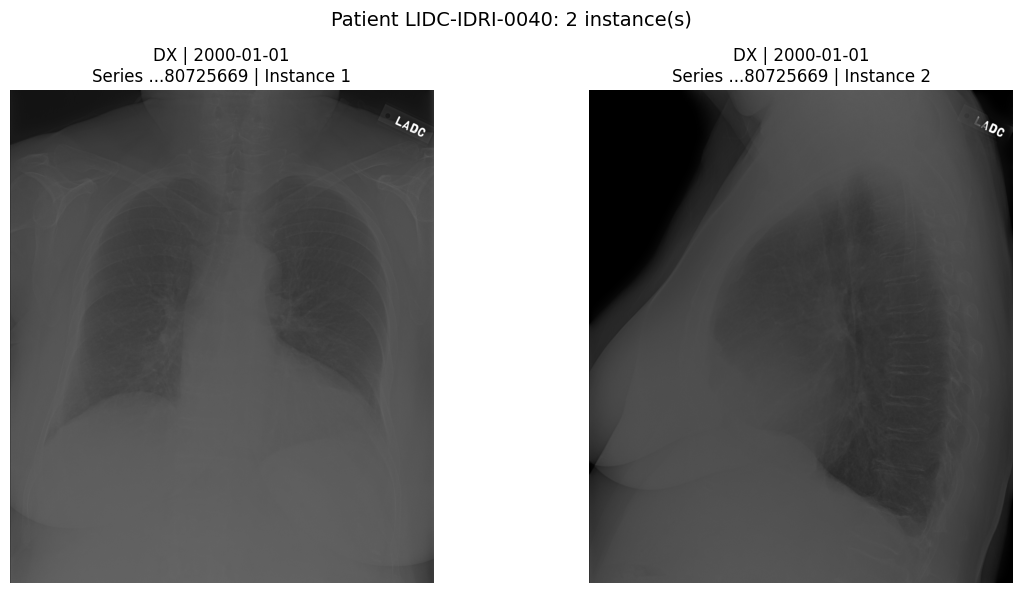

In [25]:
show_patient_instances('LIDC-IDRI-0040', manifest_df);